# Phase 4: Modeling

**CRISP-DM Purpose:** Fit the explanatory panel OLS models and produce coefficient
tables and residual diagnostics.  No data transformations happen here — the
modeling matrix is consumed as-is from Phase 3.

**Project:** Safehouse Outcome Drivers — Panel Regression
**Depends on:** Phase 3 signed off; `data/processed/panel_model_ready.csv` present
**Features:** 5 contemporaneous + 5 lag-1 program inputs + months_since_start (11 total)

**Estimator:** `linearmodels.PanelOLS` with safehouse entity effects (within estimator)
**SE type:** HC1-robust (heteroscedasticity-robust White sandwich; HC3 not available for FE panel models)
**R² metric:** Within-R² (after removing entity-level means)
**Region dummies:** excluded — collinear with entity FE (each safehouse = one region)

**Deliverables this phase:**
1. Fitted results for Model A (`avg_health_score`) and Model B (`avg_education_progress`)
2. Side-by-side coefficient table with β, SE, p-value, significance stars
3. R² directional framing (within-FE variation explained; not PASS/FAIL)
4. Residual plots — safehouses outside ±2 SD auto-flagged
5. Coefficient table saved to `artifacts/runs/coef_table.csv`

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import (
    DATA_PROCESSED, ARTIFACTS_RUNS,
    PANEL_READY_FILE, COEF_TABLE_FILE,
    OUTCOME_HEALTH, OUTCOME_EDUCATION,
    R2_THRESHOLD_MIN,
)
from src.modeling import (
    build_panel_index,
    build_formula,
    run_panel_ols,
    extract_coef_table,
    compute_residuals,
    save_coef_csv,
    MODEL_FEATURES_STD,
)

ARTIFACTS_RUNS.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Setup complete.


---
## 4.1. Load Panel and Build MultiIndex

In [2]:
panel_csv = DATA_PROCESSED / PANEL_READY_FILE
df_raw = pd.read_csv(panel_csv)
print(f"Loaded panel: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")

panel = build_panel_index(df_raw)
print(f"MultiIndex set: (safehouse_id, month_start)")
print(f"Entities : {panel.index.get_level_values(0).nunique()} safehouses")
print(f"Periods  : {panel.index.get_level_values(1).nunique()} months")
panel.head(3)

Loaded panel: 253 rows x 31 columns
MultiIndex set: (safehouse_id, month_start)
Entities : 9 safehouses
Periods  : 38 months


metric_id   month_end  active_residents  \
safehouse_id month_start                                            
1            2023-03-01           3  2023-03-31                10   
             2023-04-01           4  2023-04-30                10   
             2023-05-01           5  2023-05-31                10   

                          avg_education_progress  avg_health_score  \
safehouse_id month_start                                             
1            2023-03-01                    56.30              3.03   
             2023-04-01                    51.90              3.07   
             2023-05-01                    51.25              3.17   

                          process_recording_count  home_visitation_count  \
safehouse_id month_start                                                   
1            2023-03-01                         1                      0   
             2023-04-01                         5                      4   
             2023-05-01                         0                      2   

                          incident_count  notes region  ... snapshot_n  \
safehouse_id month_start                                ...              
1            2023-03-01                0    NaN  Luzon  ...          1   
             2023-04-01                1    NaN  Luzon  ...          2   
             2023-05-01                0    NaN  Luzon  ...          2   

                          region_Mindanao  region_Visayas  \
safehouse_id month_start                                    
1            2023-03-01                 0               0   
             2023-04-01                 0               0   
             2023-05-01                 0               0   

                          sessions_per_resident_std  visits_per_resident_std  \
safehouse_id month_start                                                       
1            2023-03-01                   -2.002350                -1.825989   
             2023-04-01                   -1.072712                -0.465387   
             2023-05-01                   -2.288026                -1.088730   

                          occupancy_rate_std  pct_high_risk_std  \
safehouse_id month_start                                          
1            2023-03-01             2.175714          -0.514649   
             2023-04-01             2.175714          -0.514649   
             2023-05-01             2.175714          -0.514649   

                          pct_trafficked_std  pct_special_needs_std  \
safehouse_id month_start                                              
1            2023-03-01            -0.831688              -0.587312   
             2023-04-01            -0.831688              -0.587312   
             2023-05-01            -0.831688              -0.587312   

                          months_since_start_std  
safehouse_id month_start                          
1            2023-03-01                -0.983583  
             2023-04-01                -0.885069  
             2023-05-01                -0.786555  

[3 rows x 29 columns]

---
## 4.2. Formula Strings

In [3]:
formula_health    = build_formula(OUTCOME_HEALTH)
formula_education = build_formula(OUTCOME_EDUCATION)

print("Model A - Health:")
print(f"  {formula_health}")
print()
print("Model B - Education:")
print(f"  {formula_education}")

Model A - Health:
  avg_health_score ~ sessions_per_resident_std + visits_per_resident_std + pct_high_risk_std + pct_trafficked_std + pct_special_needs_std + months_since_start_std + EntityEffects

Model B - Education:
  avg_education_progress ~ sessions_per_resident_std + visits_per_resident_std + pct_high_risk_std + pct_trafficked_std + pct_special_needs_std + months_since_start_std + EntityEffects


---
## 4.3. Fit Model A â€” avg_health_score

In [4]:
res_a = run_panel_ols(panel, OUTCOME_HEALTH)
print(res_a.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       avg_health_score   R-squared:                        0.2502
Estimator:                   PanelOLS   R-squared (Between):             -0.0042
No. Observations:                 253   R-squared (Within):               0.2502
Date:                Thu, Apr 09 2026   R-squared (Overall):              0.0013
Time:                        16:45:41   Log-likelihood                    131.40
Cov. Estimator:                Robust                                           
                                        F-statistic:                      13.235
Entities:                           9   P-value                           0.0000
Avg Obs:                       28.111   Distribution:                   F(6,238)
Min Obs:                       15.000                                           
Max Obs:                       36.000   F-statistic (robust):             14.363
                            

---
## 4.4. Fit Model B â€” avg_education_progress

In [5]:
res_b = run_panel_ols(panel, OUTCOME_EDUCATION)
print(res_b.summary)

                            PanelOLS Estimation Summary                             
Dep. Variable:     avg_education_progress   R-squared:                        0.1673
Estimator:                       PanelOLS   R-squared (Between):             -0.0036
No. Observations:                     253   R-squared (Within):               0.1673
Date:                    Thu, Apr 09 2026   R-squared (Overall):             -0.0088
Time:                            16:45:41   Log-likelihood                   -1061.6
Cov. Estimator:                    Robust                                           
                                            F-statistic:                      7.9677
Entities:                               9   P-value                           0.0000
Avg Obs:                           28.111   Distribution:                   F(6,238)
Min Obs:                           15.000                                           
Max Obs:                           36.000   F-statistic (robust):

---
## 4.5. Side-by-Side Coefficient Table

Rows: 7 standardised predictors.
Columns: Î² (SD units), robust SE, p-value, significance (`.` p<0.10, `*` p<0.05, `**` p<0.01, `***` p<0.001).

In [6]:
coef_table = extract_coef_table(res_a, res_b)

display_tbl = coef_table.copy()
display_tbl.index = [f.replace("_std", "") for f in display_tbl.index]
display_tbl.columns.name = None
display(display_tbl)

,beta_A,se_A,p_A,sig_A,beta_B,se_B,p_B,sig_B
sessions_per_resident,-0.0219,0.0127,0.0872,.,0.5601,1.4246,0.6946,
visits_per_resident,-0.0068,0.0104,0.5179,,-0.7915,1.2694,0.5335,
pct_high_risk,-0.0625,0.0112,0.0,***,7.1351,1.1626,0.0,***
pct_trafficked,-0.0364,0.0116,0.0018,**,-3.22,1.6741,0.0556,.
pct_special_needs,-0.0014,0.0144,0.9222,,-6.6233,2.0152,0.0012,**
months_since_start,0.0943,0.0163,0.0,***,4.1934,1.4455,0.0041,**


---
## 4.6. R² — Directional Framing

In [ ]:
r2_a = res_a.rsquared
r2_b = res_b.rsquared

print("─" * 68)
print(f"Model A  within-R² = {r2_a:.4f}  ({r2_a*100:.1f}% of within-safehouse variation explained)")
print(f"Model B  within-R² = {r2_b:.4f}  ({r2_b*100:.1f}% of within-safehouse variation explained)")
print("─" * 68)
print()
print(
    "Interpretation:
"
    f"  Health:    the model accounts for {r2_a*100:.1f}% of month-to-month variation
"
    f"             within each safehouse — after removing the safehouse fixed effect.
"
    f"  Education: the model accounts for {r2_b*100:.1f}% of within-safehouse variation.
"
    "  Remaining variance reflects unobserved factors (staffing quality, resident
"
    "  history, programme fidelity) not captured in monthly metrics.

"
    "  The models are appropriate for directional inference — identifying which
"
    "  observable programme inputs systematically co-vary with outcomes — not
"
    "  for point prediction. This framing is confirmed in Phase 5 Evaluation."
)

---
## 4.7. Residual Plots â€” Auto-flag Â±2 SD Safehouses

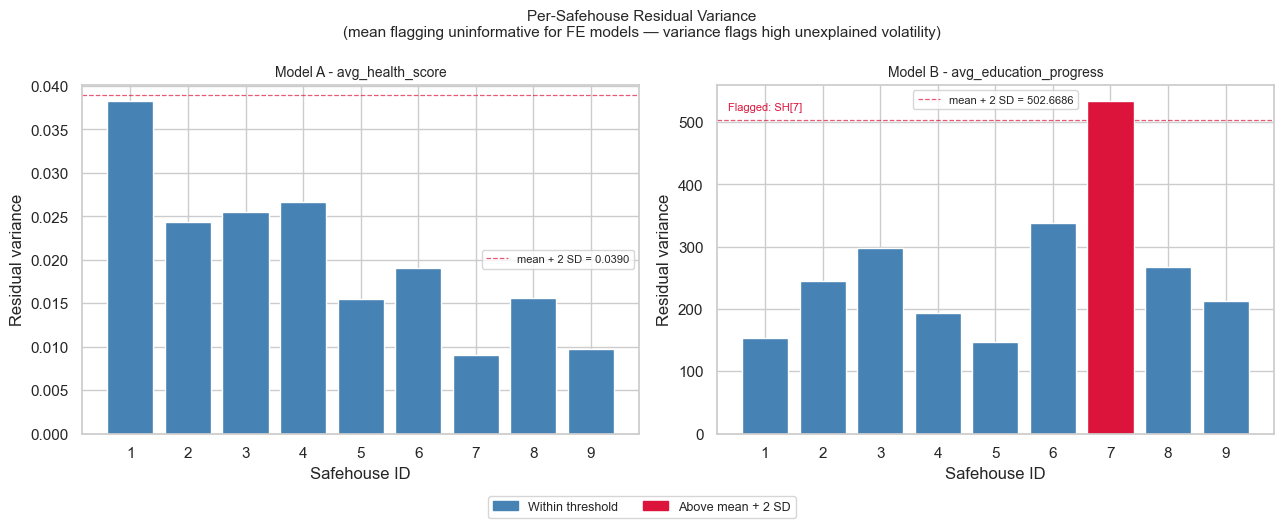


Residual variance by safehouse:


,var_A,var_B,var_A_flag,var_B_flag
safehouse_id,,,,
1,0.0382,153.0313,False,False
2,0.0243,244.6965,False,False
3,0.0255,297.2028,False,False
4,0.0267,192.9946,False,False
5,0.0154,146.4655,False,False
6,0.0190,337.1952,False,False
7,0.0090,533.0124,False,True
8,0.0156,267.3970,False,False
9,0.0098,212.1047,False,False


In [8]:
resid_by_sh = compute_residuals(res_a, res_b)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, flag_col, label in [
    (axes[0], "var_A", "var_A_flag", f"Model A - {OUTCOME_HEALTH}"),
    (axes[1], "var_B", "var_B_flag", f"Model B - {OUTCOME_EDUCATION}"),
]:
    threshold = resid_by_sh[col].mean() + 2 * resid_by_sh[col].std()
    colors = resid_by_sh[flag_col].map({True: "crimson", False: "steelblue"})

    ax.bar(resid_by_sh.index.astype(str), resid_by_sh[col],
           color=colors, edgecolor="white")
    ax.axhline(threshold, color="crimson", linewidth=0.9, linestyle="--", alpha=0.7,
               label=f"mean + 2 SD = {threshold:.4f}")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Safehouse ID")
    ax.set_ylabel("Residual variance")
    ax.legend(fontsize=8)

    flagged = resid_by_sh[resid_by_sh[flag_col]].index.tolist()
    if flagged:
        ax.annotate(f"Flagged: SH{flagged}", xy=(0.02, 0.95),
                    xycoords="axes fraction", fontsize=8,
                    color="crimson", va="top")

normal_patch = mpatches.Patch(color="steelblue", label="Within threshold")
flag_patch   = mpatches.Patch(color="crimson",   label="Above mean + 2 SD")
fig.legend(handles=[normal_patch, flag_patch], loc="lower center",
           ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=9)

plt.suptitle(
    "Per-Safehouse Residual Variance\n"
    "(mean flagging uninformative for FE models â€” variance flags high unexplained volatility)",
    fontsize=11)
plt.tight_layout()
plt.show()

print("\nResidual variance by safehouse:")
display(resid_by_sh.round(4))

---
## 4.8. Save Artifacts

In [9]:
coef_path = ARTIFACTS_RUNS / COEF_TABLE_FILE
save_coef_csv(coef_table, coef_path)
print("Artifacts saved.")

Coefficient table â†’ C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\safehouse_outcome_drivers\artifacts\runs\coef_table.csv
Artifacts saved.


---
## 4.9. Phase Evidence & Assumptions

| Decision | Value | Source |
|----------|-------|--------|
| Estimator | linearmodels PanelOLS, entity effects | User confirmed Phase 4 interview 2026-04-09 |
| SE type | HC1-robust (heteroscedasticity-robust) | linearmodels standard; HC3 not available for FE panel |
| RÂ² metric | Within-RÂ² | Appropriate for entity-effects model |
| Region dummies | Excluded â€” collinear with entity FE | User confirmed Phase 4 interview 2026-04-09 |
| occupancy_rate_std | Excluded â€” absorbed by entity FE (near-zero within-entity variance) | User confirmed Phase 4 interview 2026-04-09 |
| Coefficient layout | Side-by-side (Model A + B) | User confirmed Phase 4 interview 2026-04-09 |
| Residual flagging | Variance-based, flag > mean + 2 SD | User confirmed Phase 4 interview 2026-04-09 |
| Success threshold | Within-RÂ² â‰¥ 0.50 for each model | User confirmed Phase 1 |

---
## Phase 4 â€” Sign-off Checklist

Before proceeding to Phase 5 (Evaluation), confirm:
- [ ] Both models fit without errors (Sections 4.3, 4.4)
- [ ] Coefficient table shows Î², SE, p, sig for all 6 predictors in both models (Section 4.5)
- [ ] Within-RÂ² reported and threshold check printed for both models (Section 4.6)
- [ ] Residual variance bar chart renders; flagged safehouses annotated (Section 4.7)
- [ ] `coef_table.csv` saved to `artifacts/runs/` (Section 4.8)

**Awaiting user sign-off to proceed to Phase 5.**